# Practical 1: Data Preprocessing & File Handling

## Objective
To preprocess and analyze a high-dimensional scientific dataset (CERN electron collision data) by performing data cleaning, outlier detection, feature scaling, feature engineering, and file format conversion.

## Dataset Description
The dataset contains measurements from electron collision experiments, including energy, momentum components, angular variables, and invariant mass (M).

## Tools Used
- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn

### Step 1 : Managing working directory

In [16]:
import os

os.getcwd()
os.chdir("/content/drive/MyDrive/Deep_Learning_Practical_MSc_DS/Practical_No_1_Data_Preprocessing_and_File_Handling")
os.getcwd()

'/content/drive/MyDrive/Deep_Learning_Practical_MSc_DS/Practical_No_1_Data_Preprocessing_and_File_Handling'

### Step 2 : Import libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Step 3 : Load dataset

In [76]:
df = pd.read_csv("/content/drive/MyDrive/Deep_Learning_Practical_MSc_DS/Practical_No_1_Data_Preprocessing_and_File_Handling/dielectron.csv")
df

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.311320,10.531000,-57.29740,12.82020,-2.202670,2.177660,1,11.28360,-1.032340,-1.88066,-11.077800,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.152130,-0.579855,-5.11278,4.19242,-1.028420,-3.002840,-1,17.14920,-11.713500,5.04474,11.464700,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.480900,2.041680,22.72460,11.66100,1.420480,2.965600,1,15.82030,-1.472800,2.25895,-15.588800,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.512140,11.887100,63.86620,14.06190,2.218380,1.007210,1,25.12730,4.087860,2.59641,24.656300,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.952840,-14.622700,-59.61210,14.91790,-2.093750,-1.371540,-1,13.88710,-0.277757,-2.42560,-13.670800,2.44145,-2.423700,-1.684810,-1,2.74718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,146511,522575834,12.31310,-10.658000,5.164440,3.36858,11.84330,0.280727,2.690370,-1,1.80181,0.668609,-1.58437,0.537805,1.71967,0.307851,-1.171470,1,8.44779
99996,146511,522786431,18.46420,7.854990,15.133000,-7.08659,17.05020,-0.404510,1.092010,1,14.69110,-1.418020,-2.28117,-14.443500,2.68598,-2.383880,-2.126960,1,20.71540
99997,146511,522906124,4.18566,-3.273500,-0.308507,-2.59013,3.28801,-0.723075,-3.047630,1,72.81740,-11.074900,-9.28179,-71.369300,14.45010,-2.300410,-2.444050,-1,12.71350
99998,146511,523243830,54.46220,11.352600,11.880900,51.92400,16.43280,1.867800,0.808132,-1,8.58671,0.378009,3.07828,8.007050,3.10141,1.677170,1.448610,1,4.69670


The dataset is loaded from a CSV file containing 100,000 observations and 19 features representing physical properties of particle collisions.

In [77]:
df.columns = df.columns.str.strip()
df

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.311320,10.531000,-57.29740,12.82020,-2.202670,2.177660,1,11.28360,-1.032340,-1.88066,-11.077800,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.152130,-0.579855,-5.11278,4.19242,-1.028420,-3.002840,-1,17.14920,-11.713500,5.04474,11.464700,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.480900,2.041680,22.72460,11.66100,1.420480,2.965600,1,15.82030,-1.472800,2.25895,-15.588800,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.512140,11.887100,63.86620,14.06190,2.218380,1.007210,1,25.12730,4.087860,2.59641,24.656300,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.952840,-14.622700,-59.61210,14.91790,-2.093750,-1.371540,-1,13.88710,-0.277757,-2.42560,-13.670800,2.44145,-2.423700,-1.684810,-1,2.74718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,146511,522575834,12.31310,-10.658000,5.164440,3.36858,11.84330,0.280727,2.690370,-1,1.80181,0.668609,-1.58437,0.537805,1.71967,0.307851,-1.171470,1,8.44779
99996,146511,522786431,18.46420,7.854990,15.133000,-7.08659,17.05020,-0.404510,1.092010,1,14.69110,-1.418020,-2.28117,-14.443500,2.68598,-2.383880,-2.126960,1,20.71540
99997,146511,522906124,4.18566,-3.273500,-0.308507,-2.59013,3.28801,-0.723075,-3.047630,1,72.81740,-11.074900,-9.28179,-71.369300,14.45010,-2.300410,-2.444050,-1,12.71350
99998,146511,523243830,54.46220,11.352600,11.880900,51.92400,16.43280,1.867800,0.808132,-1,8.58671,0.378009,3.07828,8.007050,3.10141,1.677170,1.448610,1,4.69670


Column names contained unwanted spaces (e.g., 'px1 '), which can lead to errors during processing.  
These were removed using string stripping to ensure consistency and avoid KeyErrors.

### Step 4 : Understanding dataset

In [80]:
print(f"Total rows and columns in dataset:\n{df.shape}\n")
print(f"Heading of all columns:\n{df.columns.tolist()}")

Total rows and columns in dataset:
(100000, 19)

Heading of all columns:
['Run', 'Event', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']


- Dataset size: 100,000 rows and 19 columns  
- Features include energy, momentum (px, py, pz), angular variables (eta, phi), and charge  
- Target variable: Invariant mass (M)  
- All features are numerical, representing scientific measurements

### Step 5 : Inspecting dataset

In [84]:
print(df.info())
print("--------------------------------------------------------------------------")
print(df.describe())
print("--------------------------------------------------------------------------")
print("\nMissing values:\n",df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB
None
-----------------------------------

- Most features are continuous numerical variables  
- No major data type inconsistencies observed  
- Missing values detected in target variable (M)  
- Dataset appears well-structured but requires preprocessing for modeling

### Step 6 : Duplicate and missing value handling

In [85]:
print(df.duplicated().sum())
print(df.drop_duplicates(inplace=True))

print("--------------------------------------------------------------------------")

df['M'] = df['M'].fillna(df['M'].mean())
print(df.isnull().sum())


23
None
--------------------------------------------------------------------------
Run      0
Event    0
E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64


Duplicate rows were identified and removed to ensure data integrity.
A total of 23 duplicate records were found and eliminated.

The target variable (M) contained 85 missing values.  
These were handled using mean imputation to preserve dataset size and maintain statistical consistency.

### Step 7 : Outlier detection

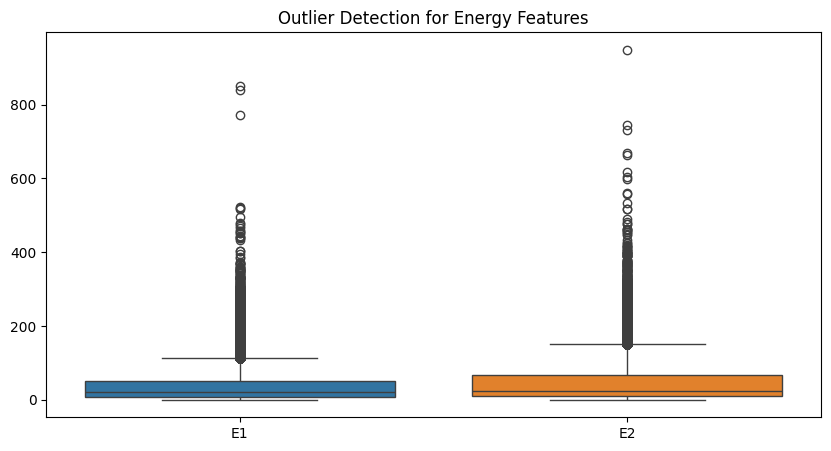

In [86]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['E1','E2']])
plt.title("Outlier Detection for Energy Features")
plt.show()

Boxplots reveal the presence of extreme values in energy features (E1 and E2).  
These outliers may represent rare high-energy collision events or noise in the data.

In [87]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_out = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original shape:", df.shape)
print("After outlier removal:", df_out.shape)

Original shape: (99977, 19)
After outlier removal: (48151, 19)


Outliers were removed using the Interquartile Range (IQR) method.

- Original dataset size: 99,977 rows  
- After outlier removal: 48,151 rows  

A significant portion of the dataset (~50%) was removed, indicating:
- Presence of extreme but potentially valid physical events  
- IQR method may be aggressive for scientific datasets  

Hence, results should be interpreted with caution.

### Step 8 : Feature Scaling

In [88]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_out)

df_scaled = pd.DataFrame(scaled_data, columns=df_out.columns)

StandardScaler was applied to normalize all features.

Since variables represent different physical quantities (energy, momentum, angles),  
scaling ensures that all features contribute equally and prevents bias due to magnitude differences.

### Step 9 : Feature Engineering

In [89]:
# Total Energy
df_scaled['Total_Energy'] = df_scaled['E1'] + df_scaled['E2']

# Momentum magnitude for particle 1
df_scaled['Momentum1'] = np.sqrt(
    df_scaled['px1']**2 + df_scaled['py1']**2 + df_scaled['pz1']**2
)

# Momentum magnitude for particle 2
df_scaled['Momentum2'] = np.sqrt(
    df_scaled['px2']**2 + df_scaled['py2']**2 + df_scaled['pz2']**2
)

df_scaled.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,...,py2,pz2,pt2,eta2,phi2,Q2,M,Total_Energy,Momentum1,Momentum2
0,-0.758721,-0.108203,2.785928,-0.854128,1.207101,-2.775408,0.376643,-1.713576,1.206716,1.010292,...,-0.264425,-0.274134,-1.153008,-1.364255,-1.154598,-0.995297,-0.777201,2.108281,3.144761,0.405053
1,-0.758721,-0.107972,-0.873613,-0.491124,-0.072138,-0.209695,-0.901585,-0.775807,-1.669648,-0.989813,...,0.618402,0.389385,0.572039,0.541628,1.497597,1.004726,-0.310077,-1.300117,0.538868,1.668008
2,-0.758721,-0.106505,0.455988,-1.333231,0.229690,1.158960,0.204905,1.179910,1.644203,1.010292,...,0.263279,-0.406911,-1.063359,-1.431400,1.174136,1.004726,1.203017,-0.027414,1.781418,0.522036
3,-0.758721,-0.108119,-0.888764,-0.641027,-0.246086,-0.086190,-0.656970,-0.299141,-1.543539,-0.989813,...,-1.155441,-0.306850,1.355709,-0.338439,-0.303018,-0.995297,-0.141290,-1.133845,0.692028,2.268153
4,-0.758721,-0.101017,-0.657562,0.113738,0.230722,-0.420621,-1.177108,-1.633323,0.593899,1.010292,...,1.606328,-1.776774,0.600545,-1.321640,0.934978,1.004726,-1.137848,0.898763,0.493042,2.407557


New features were created to enhance representation of physical properties:

- Total_Energy: Combined energy of both particles (E1 + E2)  
- Momentum1: Magnitude of momentum for particle 1  
- Momentum2: Magnitude of momentum for particle 2  

These derived features capture combined effects and improve analytical understanding.

### Step 10 : Correlation Analysis

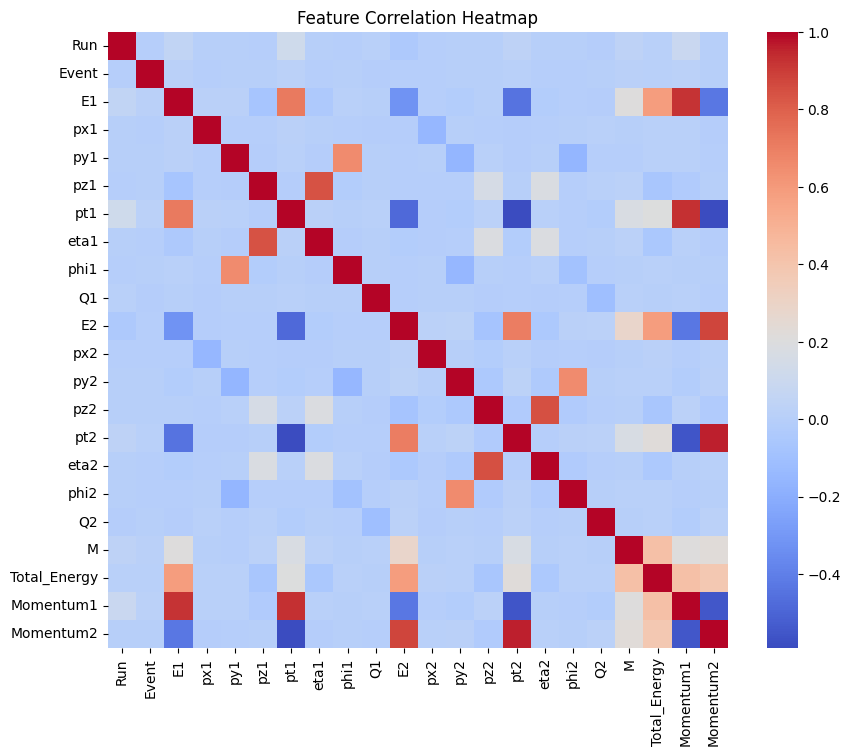

In [90]:
plt.figure(figsize=(10,8))
sns.heatmap(df_scaled.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The heatmap shows relationships between features.

- Strong correlations observed between energy and momentum variables  
- Derived features (Total_Energy, Momentum) show meaningful relationships  
- Helps identify redundant features and dependencies before modeling

### Step 11 : Distribution visualization

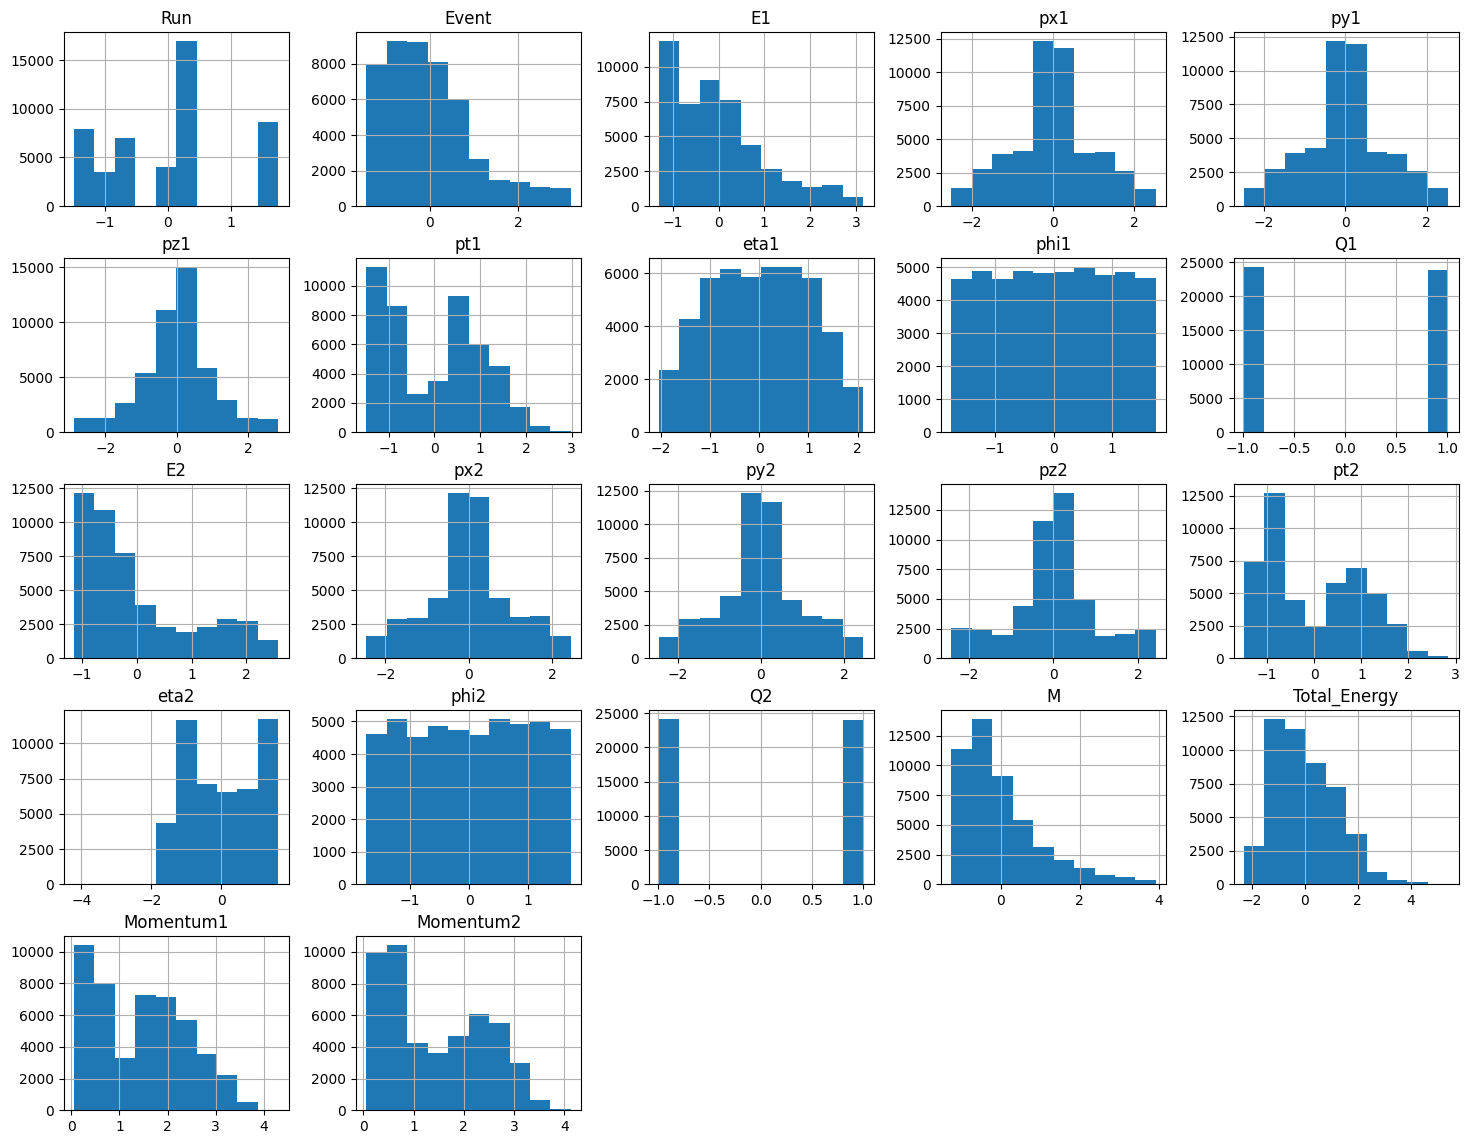

In [94]:
df_scaled.hist(figsize=(18,14))
plt.show()

Histograms reveal the distribution of features:

- Many variables exhibit skewed distributions  
- Some features show wide variation indicating diverse collision intensities  
- Confirms the necessity of scaling and preprocessing

### Step 12 : File Format Conversion

In [95]:
df_scaled.to_csv("processed_data.csv", index=False)
df_scaled.to_excel("processed_data.xlsx", index=False)
df_scaled.to_json("processed_data.json")

The processed dataset was exported into multiple formats:

- CSV → for general use  
- Excel → for reporting and analysis  
- JSON → for web and API applications  

This demonstrates flexibility in handling different data formats.

### Step 13 : Final Conclusion

In this practical:

- Performed data cleaning and preprocessing on scientific dataset  
- Handled missing values and duplicates  
- Detected and removed outliers  
- Applied feature scaling using StandardScaler  
- Created meaningful derived features  
- Analyzed feature relationships using correlation  
- Exported processed data into multiple formats  

This practical highlights the importance of preprocessing in preparing real-world data for machine learning and analytical tasks.